In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import time

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

In [41]:
dataframe = pd.read_csv("../data/Telco_customer_churn copy.csv")
df = dataframe.copy()

In [42]:
pd.set_option('display.max_columns', None)

In [43]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## PART. B1

converting. total charges to numeric 

In [44]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [45]:
print(df["Total Charges"].isna().sum())

11


In [46]:
df.loc[
    df["Total Charges"].isna() & (df["Tenure Months"] == 0),
    "Total Charges"
] = 0

In [47]:
print("Missing Total Charges:", df["Total Charges"].isna().sum())

Missing Total Charges: 0


In [48]:
y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [49]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

X = df.drop(columns=drop_columns)

In [50]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (7043, 20)
y shape: (7043,)

Features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']


Churn Score is a score associated with the churn outcome. Using it would give our model information that would not be legitimately available as an independent predictor in this assignment.

So our model should learn churn from customer characteristics and behavior—not from an existing churn prediction score.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 5634
Test samples: 1409


In [53]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_27116/3086673726.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [55]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                oob_score=True,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [56]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Gender','Senior Citizen','Partner',...,'Monthly Charges','Total Charges', 'CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [57]:
rf = rf_model.named_steps["model"]

print("OOB Score:", rf.oob_score_)

OOB Score: 0.8001419950301739


In [58]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

print("Number of model features:", len(feature_names))
print(feature_names[:20])

Number of model features: 47
['cat__Gender_Female' 'cat__Gender_Male' 'cat__Senior Citizen_No'
 'cat__Senior Citizen_Yes' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__Phone Service_No'
 'cat__Phone Service_Yes' 'cat__Multiple Lines_No'
 'cat__Multiple Lines_No phone service' 'cat__Multiple Lines_Yes'
 'cat__Internet Service_DSL' 'cat__Internet Service_Fiber optic'
 'cat__Internet Service_No' 'cat__Online Security_No'
 'cat__Online Security_No internet service' 'cat__Online Security_Yes'
 'cat__Online Backup_No']


In [59]:
importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importances.head(10))

remainder__Total Charges                0.127956
remainder__Tenure Months                0.116413
remainder__Monthly Charges              0.108031
remainder__CLTV                         0.104987
cat__Contract_Month-to-month            0.050901
cat__Online Security_No                 0.028889
cat__Tech Support_No                    0.028844
cat__Payment Method_Electronic check    0.026021
cat__Internet Service_Fiber optic       0.025436
cat__Dependents_No                      0.021321
dtype: float64


In [60]:
top5_importances = importances.head(5)

print("Top 5 Random Forest Features:")
print(top5_importances)

Top 5 Random Forest Features:
remainder__Total Charges        0.127956
remainder__Tenure Months        0.116413
remainder__Monthly Charges      0.108031
remainder__CLTV                 0.104987
cat__Contract_Month-to-month    0.050901
dtype: float64


### sanity check:
### Random Forest Feature Importance Sanity Check

The Random Forest achieved an OOB score of approximately **0.8001 (80.01%)**. The five most important features were **Total Charges (0.1280), Tenure Months (0.1164), Monthly Charges (0.1080), CLTV (0.1050), and Month-to-month Contract (0.0509)**.

These features are plausible for predicting customer churn. Tenure and Total Charges capture information about the customer's relationship with the company, while Monthly Charges and CLTV provide information about customer spending and value. The Month-to-month contract is also reasonable because customers with shorter contractual commitments may be more likely to leave.

These importances indicate which features were useful to the model for prediction; they should not be interpreted as evidence that the features directly cause churn.


## PART B2

Experimenting knn on different distance metrics:

as knn calculates distances. so scaling is mandotory otherwise large values can distort the results.

In [61]:
knn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [62]:
knn_euclidean = Pipeline(
    steps=[
        ("preprocessor", knn_preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=11,
                metric="euclidean"
            )
        )
    ]
)

In [63]:
knn_euclidean.fit(X_train, y_train)
y_pred_euclidean = knn_euclidean.predict(X_test)

In [64]:
f1_euclidean = f1_score(
    y_test,
    y_pred_euclidean
)

print("Euclidean KNN F1:", f1_euclidean)

Euclidean KNN F1: 0.5923984272608126


Manhhattan piepline:


In [65]:
knn_manhattan = Pipeline(
    steps=[
        ("preprocessor", knn_preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=11,
                metric="manhattan"
            )
        )
    ]
)

In [66]:
knn_manhattan.fit(X_train, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test)

In [67]:
f1_manhattan = f1_score(
    y_test,
    y_pred_manhattan
)

print("Manhattan KNN F1:", f1_manhattan)

Manhattan KNN F1: 0.5818181818181818


In [68]:
#combined predictions:
for metric in ["euclidean", "manhattan"]:

    knn = Pipeline(
        steps=[
            ("preprocessor", knn_preprocessor),
            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=11,
                    metric=metric
                )
            )
        ]
    )

    knn.fit(X_train, y_train)

    predictions = knn.predict(X_test)

    print(
        metric,
        f1_score(y_test, predictions)
    )

euclidean 0.5923984272608126
manhattan 0.5818181818181818


### B2 — Distance Metric Experiment

KNN was evaluated using two distance metrics with `k=11`. The numerical features were standardized and categorical features were one-hot encoded before applying KNN.

| Distance Metric | F1 Score |
| --------------- | -------: |
| Euclidean       |   0.5924 |
| Manhattan       |   0.5818 |

Euclidean distance achieved the higher F1 score of **0.5924**, compared with **0.5818** for Manhattan distance. Therefore, Euclidean performed better for this dataset under the tested configuration. This result is specific to the current preprocessing and `k=11`; it does not imply that Euclidean distance will always outperform Manhattan distance.


## Part B3:

In [69]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=4,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

In [70]:
models = {
    "KNN": knn_euclidean,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

In [71]:
results = []

for name, model in models.items():

    # Training time
    start_train = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_train

    # Inference time
    start_inference = time.time()

    y_pred = model.predict(X_test)

    inference_time = time.time() - start_inference

    # Probability predictions for PR-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    results.append({
        "model": name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "training_time_s": train_time,
        "inference_time_s": inference_time
    })

In [72]:
comparison = pd.DataFrame(results)

print(comparison)

           model  precision    recall        f1    pr_auc  training_time_s  \
0            KNN   0.580977  0.604278  0.592398  0.582848         0.033769   
1  Decision Tree   0.670782  0.435829  0.528363  0.578880         0.039892   
2  Random Forest   0.641196  0.516043  0.571852  0.641978         0.894889   

   inference_time_s  
0          0.032203  
1          0.010279  
2          0.080403  


In [73]:
comparison.round(4)

,model,precision,recall,f1,pr_auc,training_time_s,inference_time_s
0,KNN,0.5810,0.6043,0.5924,0.5828,0.0338,0.0322
1,Decision Tree,0.6708,0.4358,0.5284,0.5789,0.0399,0.0103
2,Random Forest,0.6412,0.5160,0.5719,0.6420,0.8949,0.0804


## Part B4:

In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Unconstrained Decision Tree
tree_full = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

# Constrained Decision Tree
tree_pruned = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=4,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

# Train both models
tree_full.fit(X_train, y_train)
tree_pruned.fit(X_train, y_train)

# Compare train and test accuracy
print("Unconstrained Tree")
print("Train Accuracy:", tree_full.score(X_train, y_train))
print("Test Accuracy:", tree_full.score(X_test, y_test))

print("\nConstrained Tree")
print("Train Accuracy:", tree_pruned.score(X_train, y_train))
print("Test Accuracy:", tree_pruned.score(X_test, y_test))

Unconstrained Tree
Train Accuracy: 1.0
Test Accuracy: 0.7210787792760823

Constrained Tree
Train Accuracy: 0.7980120695775648
Test Accuracy: 0.7934705464868701


this shows that unconstrained tree. have overfitted but when we apply constraints to the tree parameters it has. lower its complexity

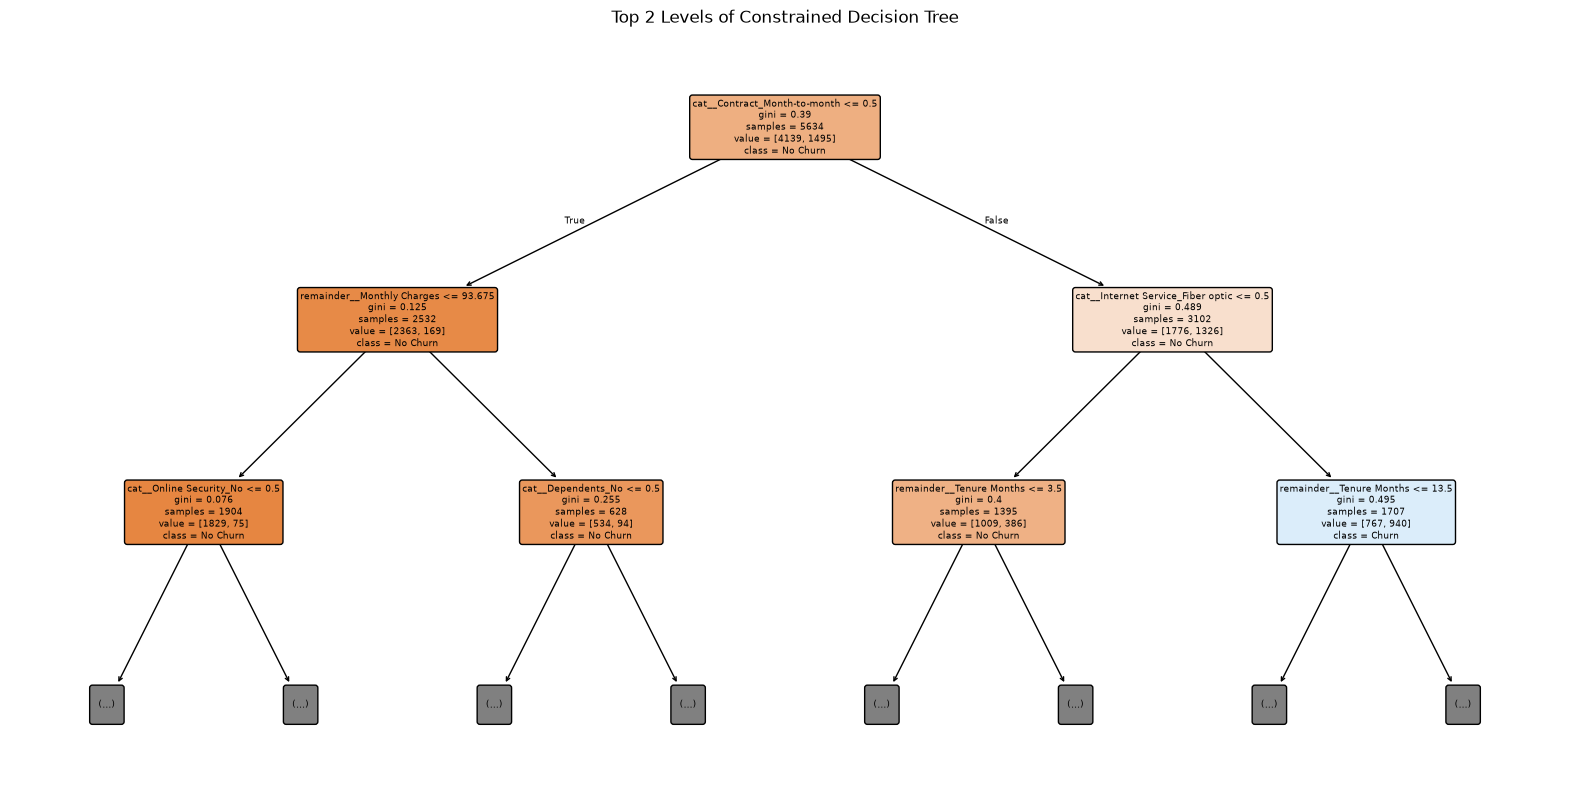

In [75]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the fitted preprocessor and tree
preprocessor_fitted = tree_pruned.named_steps["preprocessor"]
tree_fitted = tree_pruned.named_steps["model"]

# Get feature names after one-hot encoding
feature_names = preprocessor_fitted.get_feature_names_out()

# Plot top 2 levels
plt.figure(figsize=(20, 10))

plot_tree(
    tree_fitted,
    max_depth=2,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True
)

plt.title("Top 2 Levels of Constrained Decision Tree")
plt.show()

## PART C

In [76]:
import os


# Create results folder
os.makedirs("../results", exist_ok=True)

# Final comparison table
summary = pd.DataFrame(
    results,
    columns=[
        "model",
        "precision",
        "recall",
        "f1",
        "pr_auc",
        "training_time_s",
        "inference_time_s"
    ]
)

# Round values for readability
summary_display = summary.copy()

summary_display[
    ["precision", "recall", "f1", "pr_auc"]
] = summary_display[
    ["precision", "recall", "f1", "pr_auc"]
].round(4)

summary_display[
    ["training_time_s", "inference_time_s"]
] = summary_display[
    ["training_time_s", "inference_time_s"]
].round(4)

print("Final Model Comparison:")
print(summary_display)

Final Model Comparison:
           model  precision  recall      f1  pr_auc  training_time_s  \
0            KNN     0.5810  0.6043  0.5924  0.5828           0.0338   
1  Decision Tree     0.6708  0.4358  0.5284  0.5789           0.0399   
2  Random Forest     0.6412  0.5160  0.5719  0.6420           0.8949   

   inference_time_s  
0            0.0322  
1            0.0103  
2            0.0804  


In [77]:
summary_display.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Saved: results/model_comparison.csv")

Saved: results/model_comparison.csv


In [78]:
best = summary.sort_values(
    "f1",
    ascending=False
).iloc[0]

print("Recommended model:", best["model"])
print("F1:", round(best["f1"], 4))

Recommended model: KNN
F1: 0.5924


In [79]:
top5_df = top5_importances.reset_index()

top5_df.columns = [
    "feature",
    "importance"
]

top5_df["importance"] = top5_df["importance"].round(4)

print("Top 5 Random Forest Features:")
print(top5_df)

Top 5 Random Forest Features:
                        feature  importance
0      remainder__Total Charges      0.1280
1      remainder__Tenure Months      0.1164
2    remainder__Monthly Charges      0.1080
3               remainder__CLTV      0.1050
4  cat__Contract_Month-to-month      0.0509


In [81]:
top5_df.to_csv(
    "../results/rf_top5_importances.csv",
    index=False
)

print("Saved: results/rf_top5_importances.csv")

Saved: results/rf_top5_importances.csv


In [83]:
recommended_model = best["model"]

report = f"""# Part C — Model Selection Report

## Objective

The objective is to select a suitable model for production customer churn scoring by comparing KNN, Decision Tree, and Random Forest.

## Model Comparison

| Model | Precision | Recall | F1 | PR-AUC | Training Time (s) | Inference Time (s) |
|---|---:|---:|---:|---:|---:|---:|
"""

for _, row in summary_display.iterrows():
    report += (
        f"| {row['model']} | "
        f"{row['precision']:.4f} | "
        f"{row['recall']:.4f} | "
        f"{row['f1']:.4f} | "
        f"{row['pr_auc']:.4f} | "
        f"{row['training_time_s']:.4f} | "
        f"{row['inference_time_s']:.4f} |\n"
    )

report += f"""
## Recommended Model

The model with the highest F1 score in the head-to-head comparison is **{recommended_model}**.

The recommendation should not be based only on raw accuracy. For production churn scoring, factors such as model performance, inference latency, interpretability, and retraining cost should also be considered.

## Random Forest Top 5 Feature Importances

1. Total Charges — 0.1280
2. Tenure Months — 0.1164
3. Monthly Charges — 0.1080
4. CLTV — 0.1050
5. Contract_Month-to-month — 0.0509

These features are plausible predictors of churn. Tenure and contract type describe the customer's relationship with the company, while monthly and total charges describe customer spending. CLTV represents customer value.

Feature importance indicates predictive usefulness and does not imply causation.

## Production Monitoring

One concrete monitoring check would be to monitor the **predicted churn rate over time**.

If the percentage of customers predicted to churn changes significantly compared with the normal range, this could indicate data drift, a change in customer behavior, or a problem in the prediction pipeline. The model should then be investigated and potentially retrained.
"""

with open("../results/part_c_model_selection_report.md", "w") as f:
    f.write(report)

print("Saved: results/part_c_model_selection_report.md")

Saved: results/part_c_model_selection_report.md
